In [25]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

#from mpl_toolkits.mplot3d import Axes3D
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import ConstantKernel, WhiteKernel, Matern

In [26]:
df = pd.read_csv("data/output.csv")
df["rxn_concentration"] = df.concentration * df.volume
df.rename(columns={"concentration": "additive_concentration"})

num_cols = ["rxn_concentration"]
cat_col  = ["additive"] 
target_col = "lambda max wavelength" 

#X_num = df[num_cols].to_numpy(dtype=float)
encoder = OneHotEncoder(sparse_output=False)
X_cat = encoder.fit_transform(df[cat_col]) 

scaler = StandardScaler()
scaler.fit(df[num_cols])
X_num_scaled = scaler.transform(df[num_cols])

X = np.hstack([X_num_scaled, X_cat])
y = df[target_col].to_numpy(dtype=float)

In [27]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=0
)

In [28]:
n_features = X_train.shape[1]
kernel = (
    ConstantKernel(1.0, (1e-3, 1e3))
    * Matern(length_scale=np.ones(n_features), length_scale_bounds=(1e-2, 1e2), nu=1.5)
    + WhiteKernel(noise_level=1e-3, noise_level_bounds=(1e-8, 1e0))
)

gpr = GaussianProcessRegressor(
    kernel=kernel,
    alpha=1e-6,      
    normalize_y=True,
    n_restarts_optimizer=10,
    random_state=0,
)

In [32]:
gpr.fit(X_train, y_train)
y_mean, y_std = gpr.predict(X_test, return_std=True)

print("Learned kernel:", gpr.kernel_)

Learned kernel: 1.11**2 * Matern(length_scale=[1, 0.01, 0.0765, 7.28, 36.1, 7.23, 5.65, 0.917, 0.01], nu=1.5) + WhiteKernel(noise_level=0.0644)


/Users/audreymarthin/anaconda3/lib/python3.11/site-packages/sklearn/gaussian_process/kernels.py:445: ConvergenceWarning: The optimal value found for dimension 1 of parameter k1__k2__length_scale is close to the specified lower bound 0.01. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
/Users/audreymarthin/anaconda3/lib/python3.11/site-packages/sklearn/gaussian_process/kernels.py:445: ConvergenceWarning: The optimal value found for dimension 8 of parameter k1__k2__length_scale is close to the specified lower bound 0.01. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(


In [33]:
def plot_gp_1d_slice_scaled(
    gpr,
    df,
    num_cols,
    encoder,
    scaler,
    feature,
    fixed_additive,
    target_col="wavelength",
    grid_size=200
):

    f_idx = num_cols.index(feature)
    x_vals = np.linspace(df[feature].min(), df[feature].max(), grid_size)
    mean_vals = df[num_cols].mean().to_numpy()
    X_full = np.zeros((grid_size, len(num_cols) + len(encoder.categories_[0])))

    # fill all numeric values with mean, then overwrite one column
    for i in range(len(num_cols)):
        X_full[:, i] = mean_vals[i]

    X_full[:, f_idx] = x_vals

    X_num_scaled = scaler.transform(X_full[:, :len(num_cols)])
    add_vec = encoder.transform([[fixed_additive]])[0]
    X_gp = np.hstack([X_num_scaled, np.tile(add_vec, (grid_size, 1))])
    mean, std = gpr.predict(X_gp, return_std=True)
    mask = df["additive"] == fixed_additive

    plt.figure(figsize=(7,5))
    plt.scatter(
        df.loc[mask, feature],
        df.loc[mask, target_col],
        s=18,
        color="black",
        label="Observations"
    )
    plt.plot(x_vals, mean, color="blue", label="Mean prediction")
    plt.fill_between(
        x_vals,
        mean - 1.96 * std,
        mean + 1.96 * std,
        alpha=0.3,
        color="skyblue",
        label="95% CI"
    )

    plt.xlabel(feature)
    plt.ylabel(target_col)
    plt.title(f"GP for {feature} (additive={fixed_additive})")
    plt.legend()
    plt.show()


/Users/audreymarthin/anaconda3/lib/python3.11/site-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/Users/audreymarthin/anaconda3/lib/python3.11/site-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but OneHotEncoder was fitted with feature names
  warnings.warn(


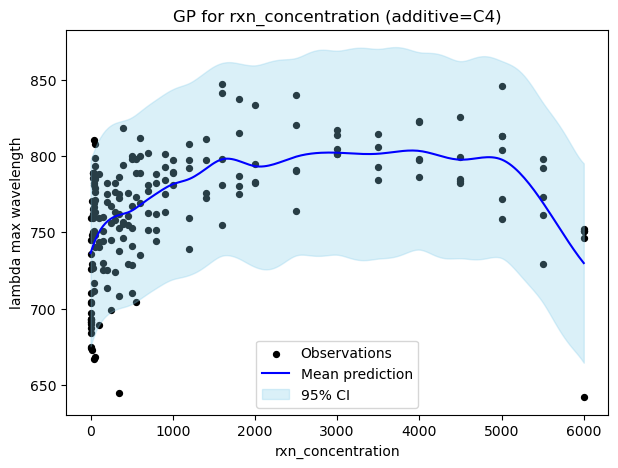

In [37]:
plot_gp_1d_slice_scaled(
    gpr=gpr,
    df=df,
    num_cols=["rxn_concentration"],
    encoder=encoder,
    scaler=scaler,
    feature="rxn_concentration",
    fixed_additive="C4",
    target_col="lambda max wavelength"
)